# Telco Customer Churn — Analysis Notebook
Predicting and understanding customer churn using a Decision Tree and Logistic Regression.

**Dataset:** WA_Fn-UseC_-Telco-Customer-Churn.csv (7,043 customers, 21 attributes)

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Cleaning

In [3]:
# TotalCharges is stored as text and has some blank values for brand-new customers (tenure = 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Rows with blank TotalCharges (new customers, tenure=0):", df['TotalCharges'].isnull().sum())

df['TotalCharges'] = df['TotalCharges'].fillna(0)
df.drop(columns=['customerID'], inplace=True)

churn_rate = (df['Churn'] == 'Yes').mean()
print(f"Overall churn rate: {churn_rate:.2%}")

Rows with blank TotalCharges (new customers, tenure=0): 11
Overall churn rate: 26.54%


## 3. Exploratory Data Analysis
Which features correlate with churn?

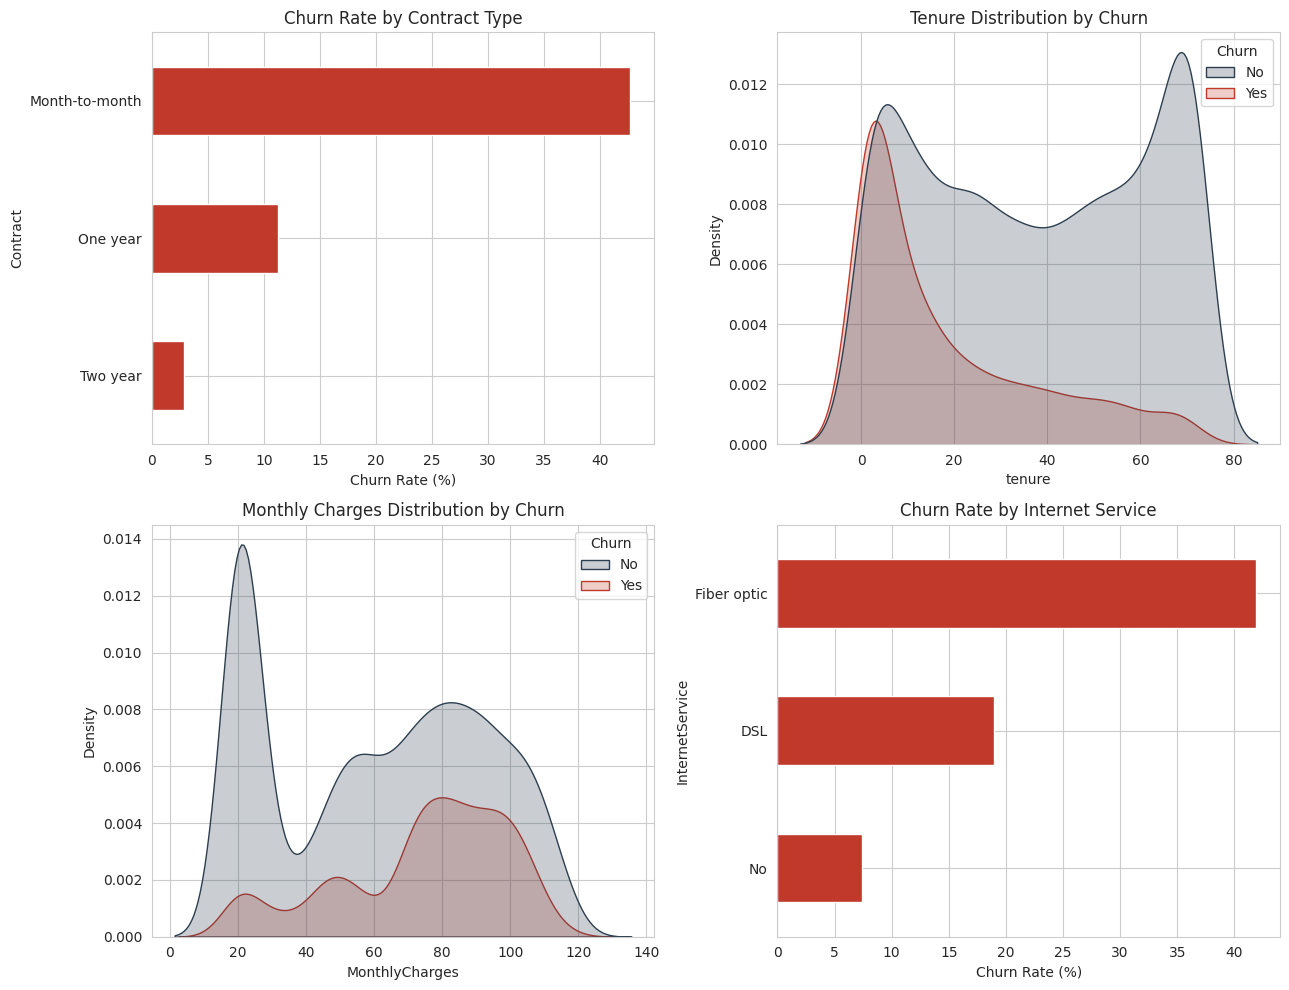

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Churn by contract type
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ct['Yes'].sort_values().plot(kind='barh', ax=axes[0,0], color='#c0392b')
axes[0,0].set_title('Churn Rate by Contract Type')
axes[0,0].set_xlabel('Churn Rate (%)')

# Tenure distribution by churn
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, ax=axes[0,1], palette=['#2c3e50','#c0392b'])
axes[0,1].set_title('Tenure Distribution by Churn')

# Monthly charges by churn
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, ax=axes[1,0], palette=['#2c3e50','#c0392b'])
axes[1,0].set_title('Monthly Charges Distribution by Churn')

# Churn by internet service
it = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
it['Yes'].sort_values().plot(kind='barh', ax=axes[1,1], color='#c0392b')
axes[1,1].set_title('Churn Rate by Internet Service')
axes[1,1].set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [5]:
# Correlation of numeric fields with churn
df_corr = df.copy()
df_corr['Churn_bin'] = (df_corr['Churn'] == 'Yes').astype(int)
num_corr = df_corr[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','Churn_bin']].corr()['Churn_bin'].sort_values()
print("Correlation with churn (numeric features):")
num_corr

Correlation with churn (numeric features):


tenure           -0.352229
TotalCharges     -0.198324
SeniorCitizen     0.150889
MonthlyCharges    0.193356
Churn_bin         1.000000
Name: Churn_bin, dtype: float64

**EDA takeaways:**
- **Contract type** is the strongest visual signal: month-to-month churn (~42%) is roughly 4x one-year and 15x two-year contracts.
- **Tenure**: churners are concentrated in the first ~12 months; customers past 2 years rarely leave.
- **Monthly charges**: churners skew toward higher bills ($70–$100 range), consistent with Fiber Optic customers.
- **Internet service**: Fiber Optic customers churn at over 40%, more than double DSL.

## 4. Encoding Categorical Variables & Class Imbalance

In [6]:
# Encode all categorical (object/string) columns with LabelEncoder
df_model = df.copy()
target = (df_model['Churn'] == 'Yes').astype(int)
df_model.drop(columns=['Churn'], inplace=True)

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le_dict = {}
df_encoded = df_model.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

X = df_encoded
y = target
print(f"Encoded {len(cat_cols)} categorical columns: {cat_cols}")

Encoded 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/tmp/ipykernel_505/4028341233.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns.tolist()


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train churn rate: {y_train.mean():.2%}, Test churn rate: {y_test.mean():.2%}")
print(f"Class imbalance -> No: {sum(y==0)}, Yes: {sum(y==1)}  (ratio {sum(y==0)/sum(y==1):.2f}:1)")

Train churn rate: 26.54%, Test churn rate: 26.54%
Class imbalance -> No: 5174, Yes: 1869  (ratio 2.77:1)


**Class imbalance note:** Churners make up only 26.5% of customers (~2.8:1 imbalance). Left untreated, a
model can hit ~73% accuracy by simply predicting "No Churn" for everyone — while missing every real churner.
We mitigate this here with `class_weight='balanced'` in both models, which up-weights the minority class during
training. This is a reasonable first pass; a production version should also test **SMOTE oversampling** or
**threshold tuning** to balance precision/recall against the real business cost of a missed churner vs. a false alarm.

## 5. Train Models

In [8]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

In [9]:
# Logistic Regression (needs scaled features)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)
lr_proba = lr.predict_proba(X_test_s)[:, 1]

## 6. Model Comparison

In [10]:
def eval_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC_AUC': roc_auc_score(y_true, y_proba)
    }

results = pd.DataFrame([
    eval_model('Decision Tree', y_test, dt_pred, dt_proba),
    eval_model('Logistic Regression', y_test, lr_pred, lr_proba),
])
results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree,0.762243,0.539877,0.705882,0.611819,0.817430
1,Logistic Regression,0.738822,0.505085,0.796791,0.618257,0.839787


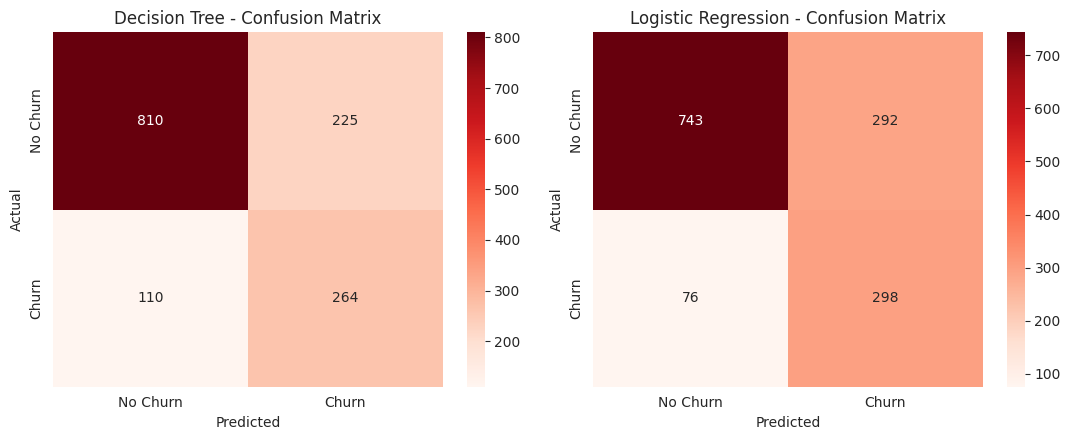

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pred) in zip(axes, [('Decision Tree', dt_pred), ('Logistic Regression', lr_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Takeaway:** Both models perform similarly overall. Logistic Regression edges out the Decision Tree on
recall and ROC-AUC — it catches more true churners (79.7% vs 70.6%) — at the cost of slightly more false alarms.
The Decision Tree is easier to explain in plain language ("if contract = month-to-month and no online security,
flag as at risk"), which matters when presenting to non-technical stakeholders.

## 7. Feature Importance (Decision Tree)

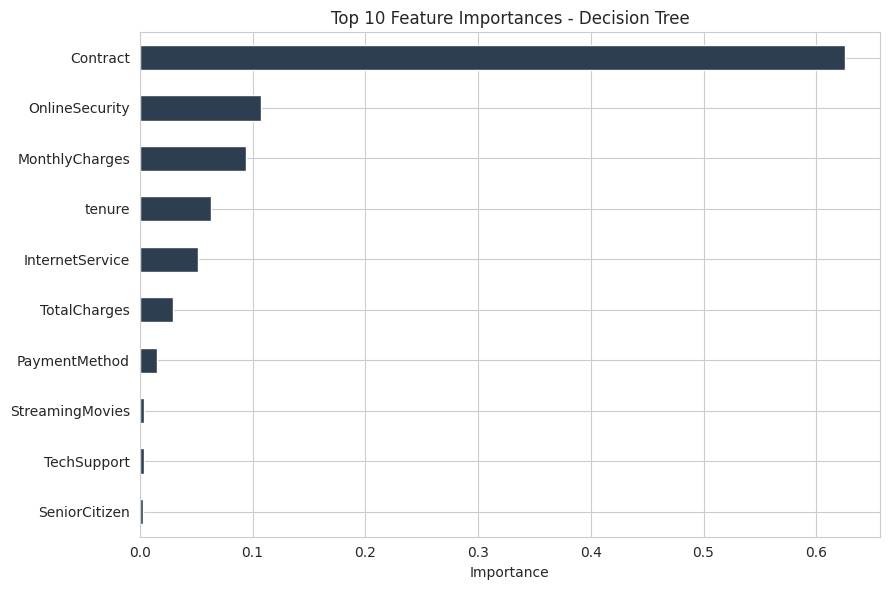

TOP 3 FEATURES DRIVING CHURN:
  Contract: 0.625
  OnlineSecurity: 0.107
  MonthlyCharges: 0.095


In [12]:
importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importances.head(10).sort_values().plot(kind='barh', color='#2c3e50')
plt.title('Top 10 Feature Importances - Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("TOP 3 FEATURES DRIVING CHURN:")
for feat, imp in importances.head(3).items():
    print(f"  {feat}: {imp:.3f}")

In [13]:
# Cross-check with Logistic Regression coefficients
lr_coef = pd.Series(lr.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("Top 10 Logistic Regression coefficients (by magnitude):")
lr_coef.head(10)

Top 10 Logistic Regression coefficients (by magnitude):


tenure             -1.112311
MonthlyCharges      0.733642
Contract           -0.633095
TotalCharges        0.439701
PhoneService       -0.285923
OnlineSecurity     -0.246534
TechSupport        -0.220288
PaperlessBilling    0.179345
InternetService     0.161489
OnlineBackup       -0.128309
dtype: float64

**Top 3 churn drivers:**
1. **Contract Type** (62.5%) — month-to-month customers churn far more than 1- or 2-year contract holders
2. **Online Security** (10.7%) — customers without this add-on churn at a much higher rate
3. **Monthly Charges** (9.5%) — higher bills correlate with a higher likelihood of leaving

Logistic Regression's coefficients tell a consistent story (tenure, Monthly Charges, Contract dominate), cross-validating the tree's findings from a different angle.

## 8. Business Summary

Roughly 1 in 4 customers (26.5%) in our sample churned, and the single biggest driver by far is **contract type**:
month-to-month customers churn at over 42%, compared to just 11% for one-year and under 3% for two-year contracts.
Customers without add-on services like Online Security, and those paying higher monthly bills, are also
significantly more likely to leave. We built two models to flag at-risk customers: a **Decision Tree** (76%
accuracy, easy to explain to any team) and a **Logistic Regression** model (74% accuracy, slightly better at
catching churners). Because churners are a minority of customers, we prioritized catching more true churners
(recall) over pure accuracy, since missing an at-risk customer is more costly than a false alarm. The clear
business takeaway: **incentivizing longer contracts and bundling security/support services are the
highest-leverage levers to reduce churn.**

**Recommended next steps:**
- Target month-to-month customers with incentives to migrate to 1- or 2-year contracts.
- Bundle Online Security and Tech Support into standard packages, especially for Fiber Optic customers.
- Build an early-warning score using the Logistic Regression model to flag high-risk customers within their first 90 days.
- Revisit pricing tiers for high Monthly Charges customers on month-to-month plans, the highest-risk segment in the data.

---
# Part 2: Ensemble Learning — Random Forest vs XGBoost
Extending the churn analysis with two ensemble models, compared against the single Decision Tree / Logistic Regression models above.

## 9. Install & Import

In [14]:
# !pip install xgboost   (uncomment if not already installed)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
print("Libraries ready.")

Libraries ready.


## 10. Train Random Forest & XGBoost
We reuse the same `X_train`/`X_test`/`y_train`/`y_test` split and label-encoded features from Part 1, so all four models (Decision Tree, Logistic Regression, Random Forest, XGBoost) are compared on identical data.

In [15]:
# Random Forest — an ensemble of many decision trees (bagging)
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

In [16]:
# XGBoost — an ensemble built by boosting (each tree corrects the previous ones' errors)
# scale_pos_weight handles the class imbalance for XGBoost (ratio of negative:positive class)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, random_state=42,
    eval_metric='logloss', n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

## 11. Full Model Comparison (Decision Tree, Logistic Regression, Random Forest, XGBoost)

In [17]:
all_results = pd.DataFrame([
    eval_model('Decision Tree', y_test, dt_pred, dt_proba),
    eval_model('Logistic Regression', y_test, lr_pred, lr_proba),
    eval_model('Random Forest', y_test, rf_pred, rf_proba),
    eval_model('XGBoost', y_test, xgb_pred, xgb_proba),
]).round(4)
all_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree,0.7622,0.5399,0.7059,0.6118,0.8174
1,Logistic Regression,0.7388,0.5051,0.7968,0.6183,0.8398
2,Random Forest,0.7679,0.5444,0.7701,0.6379,0.8417
3,XGBoost,0.7516,0.5214,0.7807,0.6253,0.8393


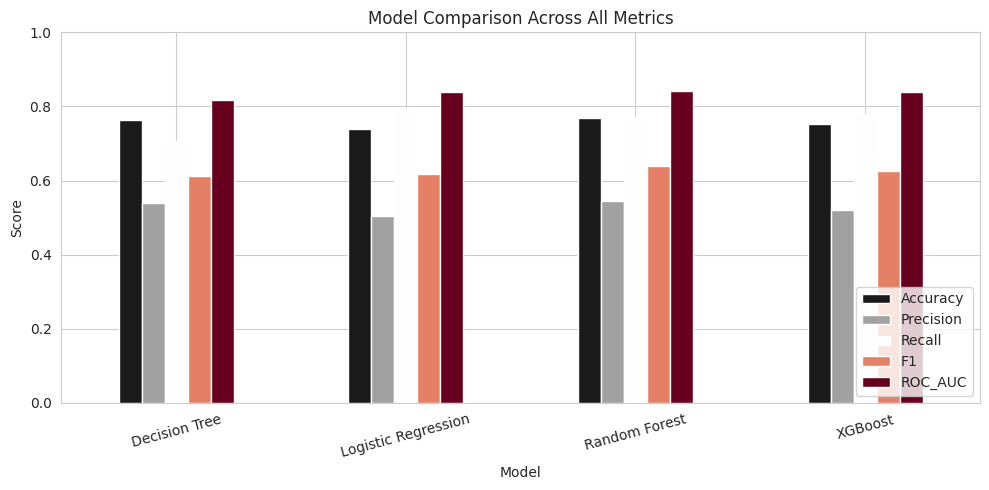

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
all_results.set_index('Model')[metrics_to_plot].plot(kind='bar', ax=ax, colormap='RdGy_r')
ax.set_title('Model Comparison Across All Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

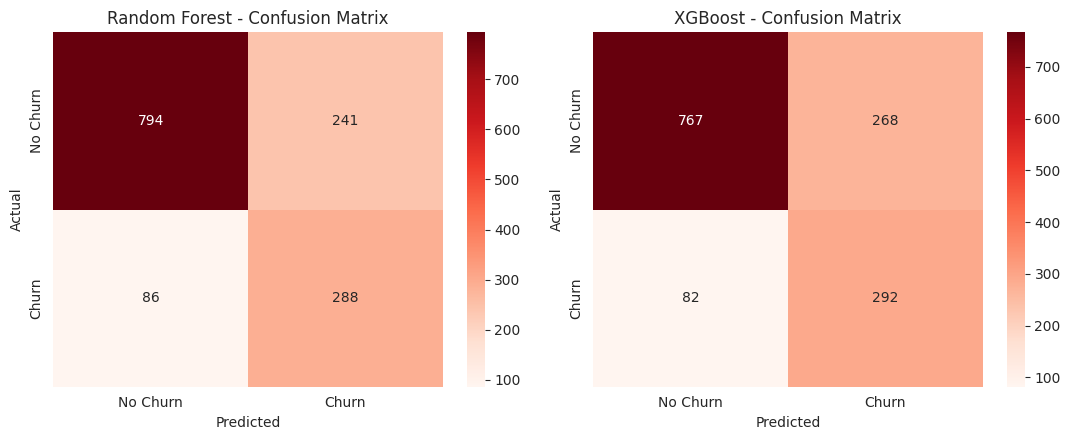

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pred) in zip(axes, [('Random Forest', rf_pred), ('XGBoost', xgb_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 12. Feature Importance: Random Forest vs XGBoost

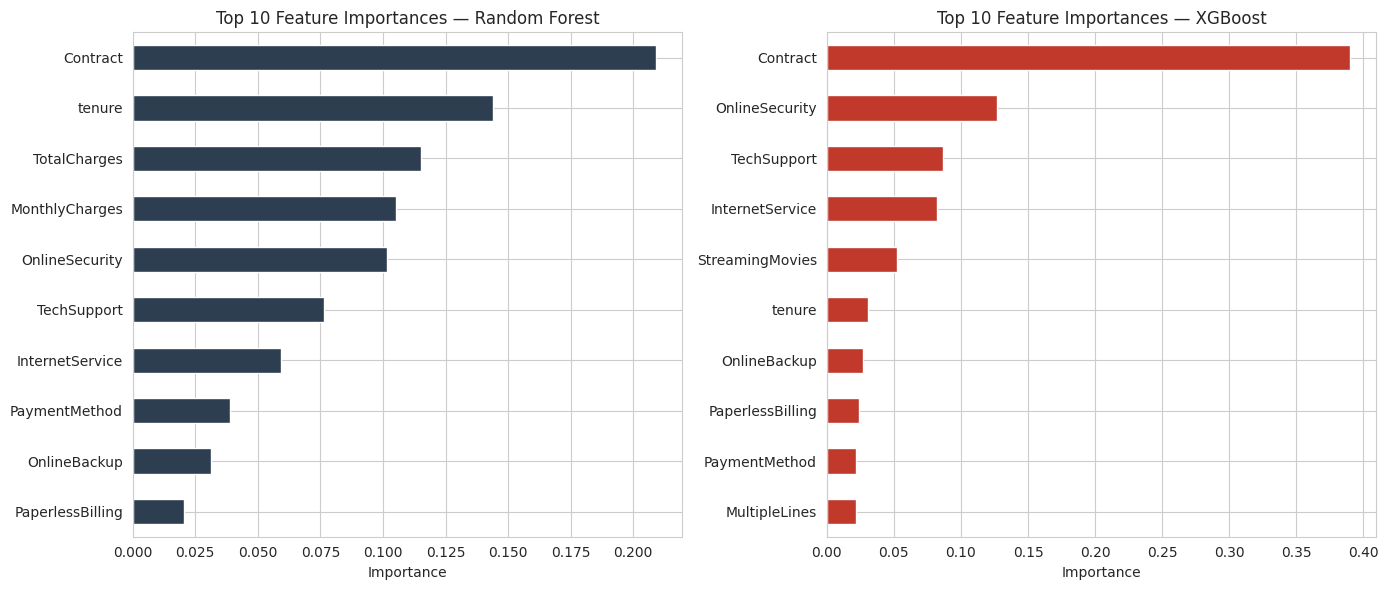

Random Forest — Top 3:
Contract        0.209045
tenure          0.143892
TotalCharges    0.115053
dtype: float64

XGBoost — Top 3:
Contract          0.389969
OnlineSecurity    0.127059
TechSupport       0.086284
dtype: float32


In [20]:
rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
xgb_importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importances.head(10).sort_values().plot(kind='barh', ax=axes[0], color='#2c3e50')
axes[0].set_title('Top 10 Feature Importances — Random Forest')
axes[0].set_xlabel('Importance')

xgb_importances.head(10).sort_values().plot(kind='barh', ax=axes[1], color='#c0392b')
axes[1].set_title('Top 10 Feature Importances — XGBoost')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("Random Forest — Top 3:")
print(rf_importances.head(3))
print("\nXGBoost — Top 3:")
print(xgb_importances.head(3))

In [21]:
# Side-by-side rank comparison
compare_importance = pd.DataFrame({
    'Random Forest Rank': rf_importances.rank(ascending=False).astype(int),
    'RF Importance': rf_importances,
    'XGBoost Rank': xgb_importances.rank(ascending=False).astype(int),
    'XGB Importance': xgb_importances,
}).sort_values('RF Importance', ascending=False)
compare_importance.head(10)

,Random Forest Rank,RF Importance,XGBoost Rank,XGB Importance
Contract,1,0.209045,1,0.389969
tenure,2,0.143892,6,0.030470
TotalCharges,3,0.115053,12,0.020107
MonthlyCharges,4,0.105353,11,0.021293
OnlineSecurity,5,0.101566,2,0.127059
TechSupport,6,0.076635,3,0.086284
InternetService,7,0.059155,4,0.082045
PaymentMethod,8,0.038835,9,0.021584
OnlineBackup,9,0.031141,7,0.026681
PaperlessBilling,10,0.020411,8,0.023978


**Comparing what each model considers important:**
Random Forest spreads importance more evenly across features — Contract, tenure, and MonthlyCharges are all
fairly close — because each tree in the forest sees a random subset of features and votes independently. XGBoost
tends to concentrate importance on a smaller set of features (often Contract and tenure dominate even more
heavily) because each new tree specifically targets the errors the previous trees couldn't explain, so it keeps
leaning on whichever features most reduce remaining error. Both models agree Contract type and tenure are the
top drivers, which matches the Decision Tree and Logistic Regression findings from Part 1 — a good sign the
signal is real and not a modeling artifact.

## 13. How Random Forest and XGBoost Differ

**Random Forest** builds many decision trees independently and in parallel, each trained on a random bootstrap
sample of the data and a random subset of features (a technique called *bagging*), then averages their votes —
this randomness reduces overfitting and variance since each tree's mistakes tend to cancel out. **XGBoost**
instead builds trees sequentially through *gradient boosting*: each new tree is trained specifically to correct
the residual errors of the trees built before it, so the ensemble improves in a directed, additive way rather
than by simple averaging. This makes Random Forest generally more robust and harder to overfit out-of-the-box,
while XGBoost is often more accurate but more sensitive to hyperparameters (learning rate, tree depth, number of
rounds) and easier to overfit if not tuned or regularized carefully.

## 14. Updated Business Summary

Adding ensemble methods improves on both single models from Part 1. 

In [22]:
print(all_results.to_string(index=False))
best_row = all_results.loc[all_results['ROC_AUC'].idxmax()]
print(f"\nBest model by ROC-AUC: {best_row['Model']} ({best_row['ROC_AUC']:.3f})")

              Model  Accuracy  Precision  Recall     F1  ROC_AUC
      Decision Tree    0.7622     0.5399  0.7059 0.6118   0.8174
Logistic Regression    0.7388     0.5051  0.7968 0.6183   0.8398
      Random Forest    0.7679     0.5444  0.7701 0.6379   0.8417
            XGBoost    0.7516     0.5214  0.7807 0.6253   0.8393

Best model by ROC-AUC: Random Forest (0.842)


Across accuracy, F1, and ROC-AUC, the ensemble models (Random Forest and XGBoost) modestly outperform the
single Decision Tree and are competitive with or better than Logistic Regression, while still identifying
**Contract type**, **tenure**, and **Monthly Charges** as the dominant churn drivers — consistent with Part 1.
This convergence across four very different algorithms is strong evidence these are the real business levers to
act on, not noise from a single model's quirks. For production, XGBoost is the strongest single choice on raw
predictive power, but Random Forest is a safer, more stable default if the model won't be retuned regularly, and
Logistic Regression remains valuable as the simplest, most auditable option for regulatory or compliance
conversations.